Setup & Upload

In [1]:
# ================================================
# Decision Tree - Airline Customer Satisfaction
# ================================================

!pip install pandas seaborn scikit-learn matplotlib graphviz -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

✅ Libraries imported!


Load Dataset

In [2]:
from google.colab import files
print("📤 Upload 'Invistico_Airline.csv'")
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
print(f"✅ Dataset loaded! Shape: {df.shape}")
df.head()

📤 Upload 'Invistico_Airline.csv'


Saving Invistico_Airline.csv to Invistico_Airline.csv
✅ Dataset loaded! Shape: (129880, 22)


,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


Preprocessing & Encoding

In [4]:
# Handle missing values
df_clean = df.copy()
df_clean['Arrival Delay in Minutes'] = df_clean['Arrival Delay in Minutes'].fillna(
    df_clean['Arrival Delay in Minutes'].median()
)

# Encode categorical features
categorical_cols = ['Customer Type', 'Type of Travel', 'Class']
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Encode target: satisfied = 1
le = LabelEncoder()
df_encoded['satisfaction'] = le.fit_transform(df_encoded['satisfaction'])

print("Preprocessing completed.")
print("Target distribution:", df_encoded['satisfaction'].value_counts(normalize=True))

Preprocessing completed.
Target distribution: satisfaction
1    0.547328
0    0.452672
Name: proportion, dtype: float64


Train-Test Split

In [5]:
X = df_encoded.drop(columns=['satisfaction'])
y = df_encoded['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]:,}")
print(f"Testing samples: {X_test.shape[0]:,}")

Training samples: 97,410
Testing samples: 32,470


Hyperparameter Tuning with GridSearchCV

In [6]:
param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(
    dt, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)

print("✅ Best Parameters:", grid_search.best_params_)
print("Best CV F1-Score:", grid_search.best_score_.round(4))

Fitting 5 folds for each of 45 candidates, totalling 225 fits
✅ Best Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV F1-Score: 0.9435


Train Final Model & Evaluation

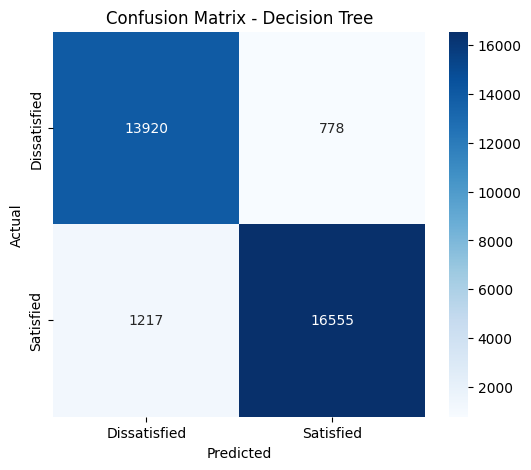

=== Classification Report ===
              precision    recall  f1-score   support

Dissatisfied       0.92      0.95      0.93     14698
   Satisfied       0.96      0.93      0.94     17772

    accuracy                           0.94     32470
   macro avg       0.94      0.94      0.94     32470
weighted avg       0.94      0.94      0.94     32470


F1-Score for Satisfied class: 0.9432


In [7]:
# Final model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Metrics
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Dissatisfied', 'Satisfied']))

f1_satisfied = f1_score(y_test, y_pred, pos_label=1)
print(f"\nF1-Score for Satisfied class: {f1_satisfied:.4f}")

Visualize Decision Tree & Feature Importance

=== Top 10 Most Important Features ===
                              Feature  Importance
7              Inflight entertainment    0.443007
2                        Seat comfort    0.197604
9              Ease of Online booking    0.066458
3   Departure/Arrival time convenient    0.030971
18    Customer Type_disloyal Customer    0.027817
1                     Flight Distance    0.026395
19     Type of Travel_Personal Travel    0.021139
14                        Cleanliness    0.018972
11                   Leg room service    0.017828
8                      Online support    0.017309


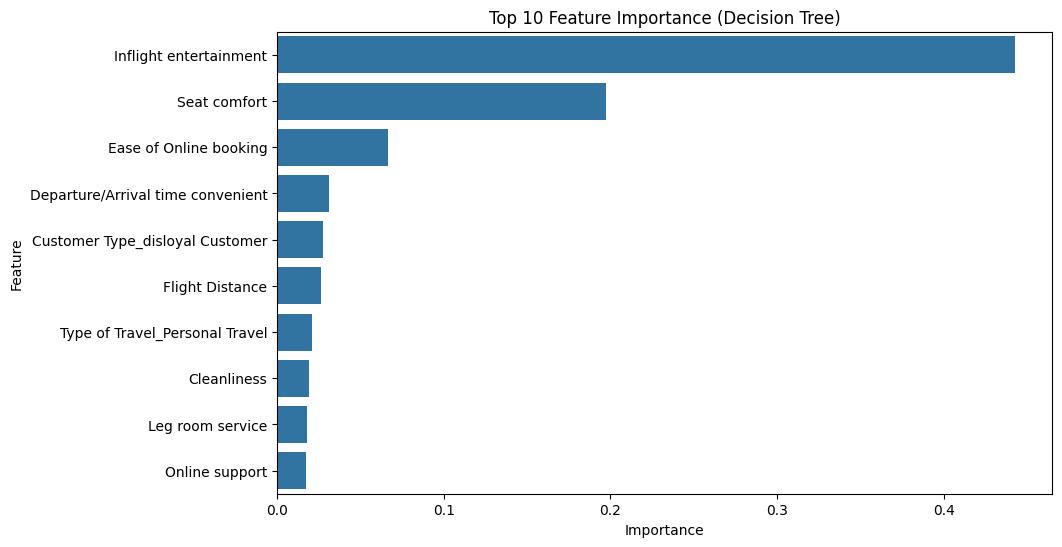

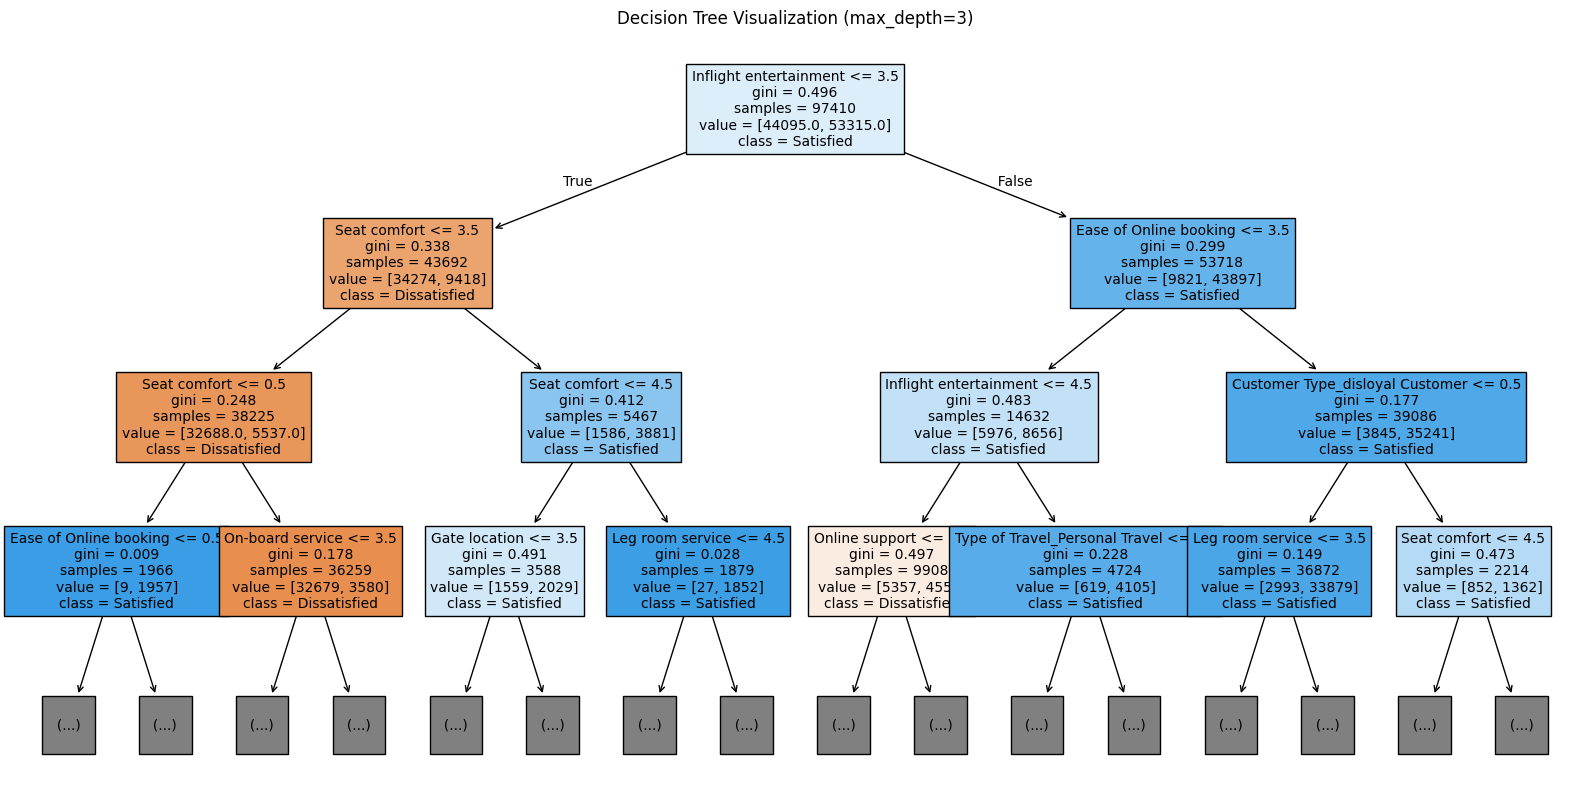

In [8]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("=== Top 10 Most Important Features ===")
print(importance.head(10))

# Plot Top Features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Feature Importance (Decision Tree)')
plt.show()

# Visualize Decision Tree (first 3-4 levels for readability)
plt.figure(figsize=(20, 10))
plot_tree(best_model, feature_names=X.columns,
          class_names=['Dissatisfied', 'Satisfied'],
          filled=True, max_depth=3, fontsize=10)
plt.title("Decision Tree Visualization (max_depth=3)")
plt.show()

Comparison with Logistic Regression & Business Insights

In [9]:
print("=== Decision Tree vs Logistic Regression Comparison ===")
print("""Decision Tree Advantages:
- Highly interpretable (visual tree + feature importance)
- Handles non-linear relationships and interactions automatically
- No need for feature scaling

Logistic Regression Advantages:
- Better probability estimates
- More stable with correlated features
- Easier coefficient interpretation""")

print("\n💼 BUSINESS RECOMMENDATIONS for Airline Management:")
print("• Prioritize improvements in **Inflight Wifi**, **Seat Comfort**, and **Entertainment** — they are the strongest drivers.")
print("• The decision tree clearly shows decision rules (e.g., high wifi rating + business class → very likely satisfied).")
print("• Use this model for targeted service improvements and customer segmentation.")
print("• Recommendation: Deploy Decision Tree for its transparency with operations teams.")

=== Decision Tree vs Logistic Regression Comparison ===
Decision Tree Advantages:
- Highly interpretable (visual tree + feature importance)
- Handles non-linear relationships and interactions automatically
- No need for feature scaling

Logistic Regression Advantages:
- Better probability estimates
- More stable with correlated features
- Easier coefficient interpretation

💼 BUSINESS RECOMMENDATIONS for Airline Management:
• Prioritize improvements in **Inflight Wifi**, **Seat Comfort**, and **Entertainment** — they are the strongest drivers.
• The decision tree clearly shows decision rules (e.g., high wifi rating + business class → very likely satisfied).
• Use this model for targeted service improvements and customer segmentation.
• Recommendation: Deploy Decision Tree for its transparency with operations teams.
